In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score

In [130]:
# Task 1: Load the diabetes dataset
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns = diabetes.feature_names)
y = diabetes.target
features = diabetes.feature_names
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
dtypes: float64(10)
memory usage: 34.7 KB


In [131]:
diabetes

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]]),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142., 155., 225.,  59

In [151]:
# Task 1: split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 55)

In [152]:
# Task 2: initialize and Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# model prediction on test data
y_pred = model.predict(X_test)

# model evaluation using r2 score
r2_eval = r2_score(y_test, y_pred)
r2_eval

0.5164122278603751

 R²: 0.5164
Optimal number of features: 8

Reduced Model Metrics:
 R²: 0.51
Plateau reached at 4 features


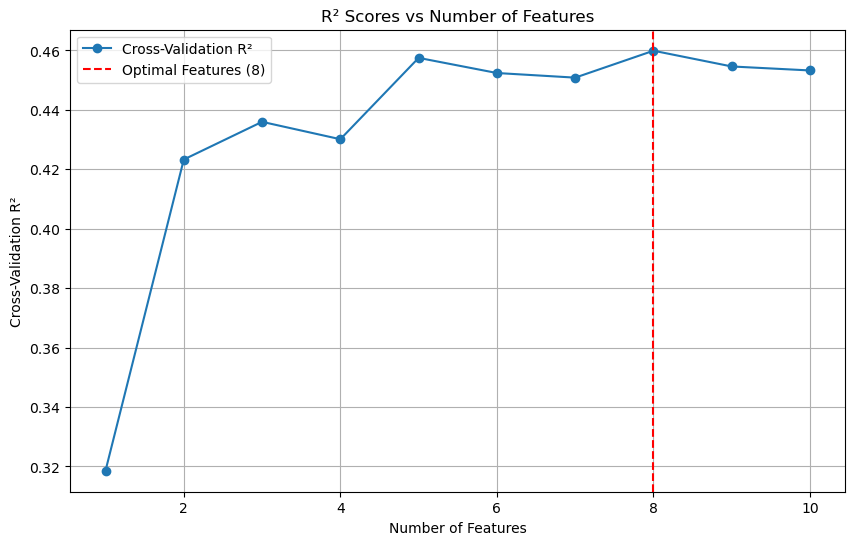

In [153]:
# Task 3: Implement Recursive Feature Elimination (RFE)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
r2_eval = r2_score(y_test, y_pred)
print(f" R²: {r2_eval:.4f}")

# Recursive Feature Elimination (RFE) with Cross-Validation
r2_scores = []
coef_hist = []
rank_history = []
num_features = []
cv_scores = []

for k in range(1, X_train.shape[1] + 1):
    rfe = RFE(estimator=LinearRegression(), n_features_to_select=k)
    rfe.fit(X_train, y_train)
    rank_history.append(rfe.ranking_)

    reduced_X_train = X_train.loc[:, rfe.support_]
    reduced_X_test = X_test.loc[:, rfe.support_]

    models = LinearRegression()
    models.fit(reduced_X_train, y_train)

    y_pred = models.predict(reduced_X_test)
    r2_eval = r2_score(y_test, y_pred)
    r2_scores.append(r2_eval)

    coefs = np.zeros(X_train.shape[1])
    coefs[rfe.support_] = models.coef_
    coef_hist.append(coefs)

    # Cross-validation to assess performance
    scores = cross_val_score(rfe, X_train, y_train, scoring='r2', cv=5)
    cv_scores.append(scores.mean())
    num_features.append(k)

# Find the optimal number of features
optimal_features = num_features[np.argmax(cv_scores)]
print(f"Optimal number of features: {optimal_features}")

# Train Final Model with Optimal Features
rfe = RFE(estimator=LinearRegression(), n_features_to_select=optimal_features)
rfe.fit(X_train, y_train)

# Reduced Model
X_train_reduced = X_train.loc[:, rfe.support_]
X_test_reduced = X_test.loc[:, rfe.support_]

reduced_model = LinearRegression()
reduced_model.fit(X_train_reduced, y_train)
reduced_pred = reduced_model.predict(X_test_reduced)

# Metrics for Reduced Model
reduced_r2 = r2_score(y_test, reduced_pred)
print("\nReduced Model Metrics:")
print(f" R²: {reduced_r2:.2f}")

for i in range(1, len(cv_scores)):
    if cv_scores[i] - cv_scores[i-1] < 0.01:
        print(f"Plateau reached at {i+1} features")
        break

# Visualize Cross-Validation Scores

plt.figure(figsize=(10, 6))
plt.plot(num_features, cv_scores, marker='o', label='Cross-Validation R²')
plt.axvline(optimal_features, color='red', linestyle='--', label=f'Optimal Features ({optimal_features})')
plt.title("R² Scores vs Number of Features")
plt.xlabel("Number of Features")
plt.ylabel("Cross-Validation R²")
plt.legend()
plt.grid()
plt.show()

In [154]:
r2_scores

[0.32062790072884617,
 0.4881093850709106,
 0.5001590404157112,
 0.5032677788282831,
 0.49789480670105823,
 0.5145753519073764,
 0.5170849630089474,
 0.5135457700316002,
 0.5169484296819287,
 0.5164122278603751]

In [156]:
coef_hist

[array([  0.       ,   0.       , 981.1643482,   0.       ,   0.       ,
          0.       ,   0.       ,   0.       ,   0.       ,   0.       ]),
 array([  0.        ,   0.        , 725.68162894,   0.        ,
          0.        ,   0.        ,   0.        ,   0.        ,
        588.04274134,   0.        ]),
 array([   0.        ,    0.        ,  727.06267814,    0.        ,
        -191.13435322,    0.        ,    0.        ,    0.        ,
         684.82539884,    0.        ]),
 array([   0.        ,    0.        ,  674.80205709,    0.        ,
        -535.48813304,  351.00325699,    0.        ,    0.        ,
         773.17695426,    0.        ]),
 array([   0.        ,    0.        ,  591.42608096,  307.63951234,
        -558.7402637 ,  357.82307183,    0.        ,    0.        ,
         700.1419487 ,    0.        ]),
 array([   0.        , -227.49935929,  555.32059164,  367.2219312 ,
        -777.65887665,  555.25268018,    0.        ,    0.        ,
         771.21127552,

In [150]:
#Task 4: Analyze Feature Importance
# create table showing coefficients
coef_tb = pd.DataFrame(coef_hist, columns = features)
coef_tb.index = range(10, 0, -1)
coef_tb

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
10,0.000000,0.000000,981.164348,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,0.000000,0.000000,725.681629,0.000000,0.000000,0.000000,0.000000,0.000000,588.042741,0.000000
8,0.000000,0.000000,727.062678,0.000000,-191.134353,0.000000,0.000000,0.000000,684.825399,0.000000
7,0.000000,0.000000,674.802057,0.000000,-535.488133,351.003257,0.000000,0.000000,773.176954,0.000000
6,0.000000,0.000000,591.426081,307.639512,-558.740264,357.823072,0.000000,0.000000,700.141949,0.000000
5,0.000000,-227.499359,555.320592,367.221931,-777.658877,555.252680,0.000000,0.000000,771.211276,0.000000
4,0.000000,-233.230257,552.542155,374.960783,-637.730312,374.411935,0.000000,127.856201,680.277378,0.000000
3,0.000000,-231.097885,553.395109,375.602868,-981.968267,623.858310,194.259930,219.608024,799.802863,0.000000
2,0.000000,-233.465463,547.434734,370.536219,-976.131398,619.093899,188.306959,213.223800,791.550361,28.797121
1,8.966927,-234.730528,547.723366,368.718214,-974.070359,616.426374,186.560795,212.920911,789.558523,27.509452
